In [1]:
import numpy as np 
import os

import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit,brentq
from scipy.integrate import ode, odeint

import Physical_Const as phys
import WD_HT as WD



#----Constants------

hbar     = phys.hbar
c        = phys.c
G        = phys.G
sigma    = phys.sigmaSB
me_mev   = phys.me
e        = phys.e
e_erg    = phys.e_erg
mevtoerg = phys.mevtoerg
mu       = phys.mu
kappaB   = phys.kappa
Msun     = phys.Msun
Rsun     = phys.Rsun

h        = hbar*(2.0*np.pi)
c2       = c*c
me       = me_mev * mevtoerg / c2


# ---Dimensions---
MA       = 2.0
Cgrav    = G * Msun / c**2
Jdim     = G / c**3

mpl      = np.sqrt(hbar * c / G) # planck mass
Rdim     = np.power( mpl / me , 2.0) * hbar / (mpl * c)
Mdim     = Rdim / Cgrav
Sigma02  = np.power( c / Rdim,2.0) / G

Sigma    = np.power(me,4.0)*np.power(c,3.0)/(8.0*np.power(np.pi,2.0)*np.power(hbar,3.0))
SigmaP   = c2 * Sigma


rhobeta  = np.log10(3.9e10)


/home/laura/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
rhoEoS, xeEoS, PEoS, PsatEoS, chip_EoS = np.loadtxt("../C12_with_elec_energy.dat",usecols=(0,1,2,3,4),unpack=True)
rhoi  = np.log10( rhoEoS[0] )
rhof  = np.log10( rhoEoS[-1] )
xemin = xeEoS[0]
xemax = xeEoS[-1]
NN    = 100

# --- Degenerate electronic Pressure -----
def Pch_EoS(x):
    pWD = SigmaP*(x*np.sqrt(1.0+np.power(x,2.0))*(2.0*np.power(x,2.0)/3.0-1.0)+np.log(np.sqrt(1.0+np.power(x,2.0))+x))
    return pWD

def func(x, b):
    return ( np.power(10.0,rhof) / Sigma02 ) * np.power(x,b)/np.power(xemax,b)

#---find best fit-----
popt, pcov = curve_fit(func, xeEoS , rhoEoS / Sigma02)
afit = popt[0]

log_xXe = np.linspace(np.log10(xeEoS[0]*0.5),np.log10(xeEoS[-1]*1.5),NN)

xx_xe   = np.power(10.0,log_xXe)
EOS1    = np.zeros((2,NN))

#Create grid to fit fuction and calculate denrivatives EoS-------
for i in range(NN):
    xi = xx_xe[i]
    PP = Pch_EoS(xi)
    EOS1[0,i] = func(xi,afit)
    EOS1[1,i] = PP / ( c**2*Sigma02 )


DeDp_2 = []
DxeF   = 0.01
for i in range(NN):
    dx = xx_xe[i]*DxeF
    if i==0:
        Der = (func(xx_xe[i]+dx,afit) - EOS1[0][i]) / ( Pch_EoS(xx_xe[i]+dx) / (c**2*Sigma02) - EOS1[1][i])
    else:
        Der = (func(xx_xe[i]+dx,afit)-func(xx_xe[i]-dx,afit)) / (Pch_EoS(xx_xe[i]+dx)/(c**2*Sigma02)-Pch_EoS(xx_xe[i]-dx)/(c**2*Sigma02))
    DeDp_2.append(Der)

DeDpF       = interp1d(np.log10(EOS1[1]),  np.log10(DeDp_2),kind='cubic')
EoS_RFMT    = interp1d( EOS1[0], EOS1[1], kind='cubic' )
EoS_RFMT_02 = interp1d( EOS1[1], EOS1[0], kind = 'cubic')


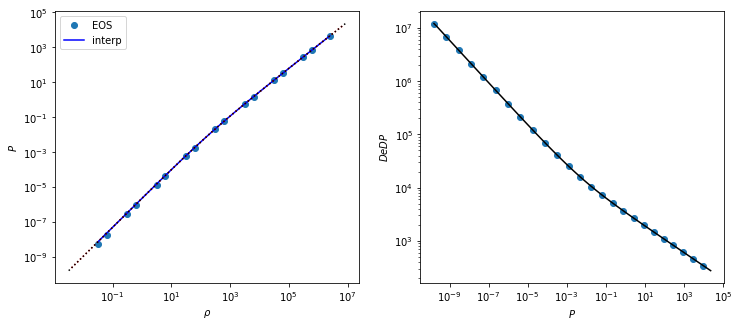

In [3]:
fig = plt.figure(figsize=(12,5))

plt.subplot(121)
x    = np.linspace(rhoi,rhof,100)
Pmin = np.log10(EOS1[1][1]); Pmax=np.log10(EOS1[1][-2])
xp   = np.linspace(Pmin,Pmax,100)

plt.loglog( rhoEoS/Sigma02, Pch_EoS(xeEoS)/ ( c**2*Sigma02 ),'o', label="EOS")

plt.loglog( np.power(10,x)/Sigma02, EoS_RFMT(np.power(10,x)/Sigma02), 'b-', label="interp")
plt.loglog( EoS_RFMT_02(np.power(10,xp)), np.power(10,xp) ,'r:')
plt.loglog( EOS1[0], EOS1[1],'k:')

plt.legend()

plt.xlabel("$\\rho$")
plt.ylabel("$P$")

plt.subplot(122)
#---Plot derivative EoS-----
Pmin = np.log10(EOS1[1][0]) 
Pmax = np.log10(EOS1[1][-1])
x    = np.linspace(Pmin,Pmax,100)

plt.loglog(EOS1[1][::4],DeDp_2[::4],'o')
plt.loglog(np.power(10,x),np.power(10,DeDpF(x)),'k-')

plt.xlabel("$P$")
plt.ylabel("$DeDP$")

plt.show()


## TOV Equations: Non-Rotating case

$$ \frac{dm}{dr}=4\pi r^2 \rho $$
$$ \frac{d\nu}{dr}=\frac{2(4\pi r^3 p +m)}{r(r-2m)} $$
$$ \frac{dp}{dr}=-\frac{1}{2}(p+\rho)\frac{d\nu}{dr}$$

### TOV: HT Rotating Case (up to first order in $\Omega$)
$$ \frac{d\omega}{dr}=f$$
$$ \frac{df}{dr} = \frac{4\pi r^2 (p+\rho) }{r-2m}\left(\frac{4\omega}{r}+f\right) -4\frac{f}{r}$$

### TOV: HT Rotating Case (up to second order in $\Omega$)
$$\frac{dm_0}{dr}= 4\pi r^2 \rho_{l=0} + \frac{8}{3}e^{-\nu}\pi r^4 (p+\rho)\omega^2 + \frac{1}{12}e^{-\nu}r^3(r-2m)\left(\frac{d\omega}{dr}\right)^2$$

$$ \frac{dp^{*}_0}{dr}=-\frac{m_0(1+8\pi r^2 p)}{(r-2m)^2 }-\frac{4\pi r^2 P_{l=0}}{r-2m} +\frac{1}{3}e^{-\nu}\left(\omega^2 (2r-r^2\frac{d\nu}{dr}) +2r^2\omega\frac{d\omega}{dr} +\frac{r^3}{4}\left(\frac{d\omega}{dr}\right)^2\right)$$

$$ \rho_{l=0} = p^{*}_{l=0}(p+\rho)\frac{dE}{dP} $$
$$ P_{l=0} = p^{*}_{l=0}(p+\rho) $$

$$ \frac{dv}{dr}=-h_2\frac{d\nu}{dr} + \frac{1}{2}e^{-\nu}\left(2+r\frac{d\nu}{dr}\right) \left[\frac{8}{3} \pi \omega^2 r^3(p+\rho) + \frac{1}{6}r^2(r-2m)\left(\frac{d\omega}{dr}\right)^2\right]$$

$$ \frac{dh_2}{dr}= -h_2\frac{d\nu}{dr} - \frac{4h_2(m -2\pi r^3 (p+\rho))}{r^2(r-2m) \nu'}-\frac{2v}{m+4\pi r^3p}+ \frac{e^{-\nu}}{6}\left[\frac{-r^2}{ \nu'} + \frac{r^3(r-2m)\nu'}{2 }\right]\left(\frac{d\omega}{dr}\right)^2 +\frac{4\pi r^3 (p+\rho)\omega^2 e^{-\nu}}{3}\left(r\nu' +\frac{2}{(r-2m)\nu'}\right)$$

In [4]:
# Keplrian Sequence

file_name = "./KepSeqWD_RMTF.dat"
writeKep = True

dr = 1e-6
rf = 1.0

Mmax = WD.EoS_Mmax( np.power(10.0,rhoi*2)/Sigma02, np.power(10.0,rhof)/Sigma02, dr, rf, EOS1)
Mmax[1]*Mdim

Nm    = 10
rhomaxS = np.log10(Mmax[0]*Sigma02)
rhocc   = np.linspace(rhoi*2.5, rhobeta,Nm)
rhons   = np.power(10.0,rhocc)/Sigma02
pc      = EoS_RFMT( rhons )

MR_kep = np.zeros((Nm, 8))

if not writeKep:
    if os.path.isfile(file_name):
        print("The keplerian Sequence has been already done......")
        rhowd_kep, pwd_kep, Mstawd_kep, Rstawd_kep, Mrotwd_kep, Rrotwd_kep, Jwd_kep, Omegawd_kep =np.loadtxt(file_name,usecols=(0,1,2,3,4,5,6,7),unpack=True)

else:
    for i in range(Nm):
        dedp0 = np.power(10,DeDpF( np.log10( pc[i] ) ))
        y0i = WD.IntCond_Static( rhons[i], pc[i], dr )
        MS  = WD.StaticSeq( y0i , dr, rf, EOS1 )
        
        OK  = WD.OmegaK( MS[0], MS[1], 0, 0 , 0 )
    
        y0i = WD.IntCond_Rotating( OK, MS[4], rhons[i], pc[i], MS[2], dr , rf , EOS1, dedp0 )   
        MR  = WD.MassRadius(y0i, dr, rf,  EOS1, DeDp_2 )

        OK  = WD.OmegaK( MR[0] , MR[1] , MR[6]-MR[0],  MR[3] / MR[0]**2.0, 0.0*MR[5] / MR[0]**3.0 )
        cut=0
        while np.abs(MR[4]-OK)>1e-4 and cut<80:
            y0i = WD.IntCond_Rotating( OK, MS[4], rhons[i], pc[i], MS[2], dr , rf , EOS1, dedp0 )   
            MR  = WD.MassRadius(y0i, dr, rf,  EOS1, DeDp_2 )
            OK  = WD.OmegaK( MR[0] , MR[1] , MR[6]-MR[0],  MR[3] / MR[0]**2.0, 0.0*MR[5] / MR[0]**3.0 )
            cut += 1
        MR_kep[i] = MR
        print(i, MR[4], OK)

    with open(file_name, "w") as file:
        for i in range(Nm):
            line1 = [ rhocc[i], pc[i], MR_kep[i][0], MR_kep[i][1], MR_kep[i][6], MR_kep[i][7], MR_kep[i][3], MR_kep[i][4] ]
            np.savetxt(file,[line1], fmt='%.8e')
            file.flush()

    rhowd_kep, pwd_kep, Mstawd_kep, Rstawd_kep, Mrotwd_kep, Rrotwd_kep, Jwd_kep, Omegawd_kep =np.loadtxt(file_name,usecols=(0,1,2,3,4,5,6,7),unpack=True)

    
    

0 15.733861500744638 15.733900551681323
1 23.476731889501 23.476741179681177
2 34.015745340226374 34.015797883715436
3 49.22730451810026 49.227328463105216
4 71.16706384724161 71.16711727416624
5 103.57350188975612 103.57352767490794
6 152.8037989979838 152.80388818540524
7 227.88827132957397 227.88832622671922
8 343.89451092183305 343.89454660563973
9 526.0273112895158 526.0273295998041


In [ ]:
# Secular Instability Sequence
file_name = "./SecularInstability_RMTF.dat"
writeSec = True

minj = 1e-3*(Jwd_kep*1e13).min()
maxj = 8e-1# (Jwd_kep*1e13)[-1]

Nm = 10
MR_wdmax = np.zeros((Nm, 8))
rhomax   = np.zeros(Nm)

j_grid = np.linspace( minj, maxj, num=Nm)

dr = 1e-6
rf = 1.0

if not writeSec:
    if os.path.isfile(file_name):
        print("The Secular Instability Sequence has been already done......")
        rhowd_seq,pwd_seq,Mstawd_seq,Rstawd_seq,Mrotwd_seq,Rrotwd_seq,Jwd_seq,Omegawd_seq,Qwd_seq,Omegakwd_seq=np.loadtxt(file_name,usecols=(0,1,2,3,4,5,6,7,8,9),unpack=True)
else:
    for i in range(Nm):
        WDmax = WD.EoS_RoTMmax( np.power(10.0,rhoi*3)/Sigma02, np.power(10.0,rhof)/Sigma02, 1e-13*j_grid[i], dr, rf, EOS1, DeDp_2 )
        #print(WDmax[1]*Mdim)

        rhomax[i] = WDmax[0]
        pc        = EoS_RFMT(WDmax[0])
        dedpc     = np.power(10,DeDpF( np.log10(pc)) )

        y0i = WD.IntCond_Static( WDmax[0], pc , dr )
        MS  = WD.StaticSeq( y0i , dr, rf, EOS1 )
    
        y0i   = WD.IntCond_Rotating( 1e-13*j_grid[i] , MS[3], WDmax[0], pc, MS[2], dr , rf , EOS1, dedpc )
        OOp   = WD.MassRadius(y0i, dr, rf,  EOS1, DeDp_2 )
        MR_wdmax[i] = OOp

        if np.log10(WDmax[0]*Sigma02)>rhobeta:
            Nm = i
            break

    with open(file_name, "w") as file:
        for i in range(Nm):
            pc = EoS_RFMT( rhomax[i] )
            OK  = WD.OmegaK(  MR_wdmax[i][0] ,  MR_wdmax[i][1] ,  MR_wdmax[i][6]- MR_wdmax[i][0],   MR_wdmax[i][3] /  MR_wdmax[i][0]**2.0,  MR_wdmax[i][5] /  MR_wdmax[i][0]**3.0 )
            line1 = [ np.log10(rhomax[i]*Sigma02), pc, MR_wdmax[i][0], MR_wdmax[i][1], MR_wdmax[i][6], MR_wdmax[i][7], MR_wdmax[i][3], MR_wdmax[i][4], MR_wdmax[i][4], OK]
            np.savetxt(file,[line1], fmt='%.8e')
            file.flush()


    rhowd_seq,pwd_seq,Mstawd_seq,Rstawd_seq,Mrotwd_seq,Rrotwd_seq,Jwd_seq,Omegawd_seq,Qwd_seq,Omegakwd_seq=np.loadtxt(file_name,usecols=(0,1,2,3,4,5,6,7,8,9),unpack=True)



In [ ]:
dr = 1e-6
rf = 1.0

Mmax_sta = Mstawd_kep.max()
Mmax_rot = Mrotwd_kep.max() 

print("#############################################################")
print("Maximun static mass: ", Mmax_sta*Mdim )
print("Maximun rotating mass: ", Mmax_rot*Mdim )
print("#############################################################")

imax = Mrotwd_kep.argmax()
Kep_rho = interp1d( Mrotwd_kep[:imax]*Mdim,rhowd_kep[:imax], kind='cubic' )
imax = Mstawd_kep.argmax()
Sta_rho = interp1d(  Mstawd_kep[:imax]*Mdim, rhowd_kep[:imax], kind='cubic' )

Nm = 5
MWD = 1.39
MrotCons=np.zeros(Nm)

# define range in the density
XKep = Kep_rho(MWD)

if MWD<( Mmax_sta*Mdim) :
    Xsta = Sta_rho(MWD)
else:
    Xsta = rhobeta

MR_c = np.zeros((Nm, 8))

rho_grid  = np.linspace( XKep, Xsta-0.01, num=Nm)
rhoc_grid = np.power(10.0, rho_grid) / Sigma02
pc_grid   = EoS_RFMT(rhoc_grid)
dedp_grid = DeDpF( np.log10( pc_grid ) )
dedp_grid = np.power(10, dedp_grid)

for i in range(Nm):
    #print( i, rhoc_grid[i], pc_grid[i])

    y0i = WD.IntCond_Static( rho_grid[i], pc_grid[i], dr )
    MS  = WD.StaticSeq( y0i , dr, rf, EOS1 )
        
    Ji = 0.0
    Jl = 10*1e50*G/(Rdim**2*np.power(c,3))
    
    y0i   = WD.IntCond_Rotating( 0.5*(Ji+Jl), MS[3], rho_grid[i], pc_grid[i], MS[2], dr , rf , EOS1, dedp_grid[i] )
    OOp   = WD.MassRadius(y0i, dr, rf,  EOS1, DeDp_2 )
    cut   = 0
    while np.abs( OOp[6]*Mdim - MWD ) > 1e-3 and cut<50:
        if OOp[6]*Mdim-MWD > 0.0:
            Jl = (Ji+Jl)/2.0
        else:
            Ji = (Ji+Jl)/2.0
        y0i   = WD.IntCond_Rotating( 0.5*(Ji+Jl), MS[3], rho_grid[i], pc_grid[i], MS[2], dr , rf , EOS1, dedp_grid[i] )
        OOp   = WD.MassRadius(y0i, dr, rf,  EOS1, DeDp_2 )
        cut=cut+1
    
    MR_c[i] = OOp
    


In [ ]:
file_name = "./CConstMass"
file_name = "_".join([file_name,str(MWD*100)[0:3]])
file_name = "".join([file_name,".dat"])

with open(file_name, "w") as file:
    for i in range(Nm):
        OK  = WD.OmegaK(  MR_c[i][0] ,  MR_c[i][1] ,  MR_c[i][6]- MR_c[i][0],   MR_c[i][3] /  MR_c[i][0]**2.0,  MR_c[i][5] /  MR_c[i][0]**3.0 )
            
        line1 = [ rho_grid[i], pc_grid[i], MR_c[i][0], MR_c[i][1], MR_c[i][6], MR_c[i][7],MR_c[i][7], MR_c[i][3], MR_c[i][4], MR_c[i][5], OK ]
        np.savetxt(file,[line1], fmt='%.8e')
        file.flush()

In [ ]:
fig=plt.figure(figsize=(8,5))

plt.plot( rhowd_kep,   Mstawd_kep*Mdim , "k-")
plt.plot( rhowd_kep,   Mrotwd_kep*Mdim , "k-")

plt.plot( rho_grid ,   MR_c[:,6]*Mdim , "b.")

plt.plot(rhowd_seq,   Mrotwd_seq*Mdim , "b-")

plt.axhline( y = Mmax[1]*Mdim, color = 'gray', ls=':')
plt.vlines( x = rhobeta, ymin=Mmax[1]*Mdim, ymax=1.56,color = 'red', ls=':')

plt.xlabel( "$log (\\rho\,  [\, g \, cm^{-3}\, ]\, )$  ")
plt.ylabel( "$M [M_\\odot]$")

#plt.xlim(0.0,2)

plt.show()

In [ ]:
fig=plt.figure(figsize=(8,5))

plt.plot( Rstawd_kep*Rdim/Rsun,   Mstawd_kep*Mdim , "k-")
plt.plot( Rrotwd_kep*Rdim/Rsun,   Mrotwd_kep*Mdim , "k-")

plt.plot(Rrotwd_seq*Rdim/Rsun,   Mrotwd_seq*Mdim , "b-")

plt.xlabel( "$R [R_\\odot]$  ")
plt.ylabel( "$M [M_\\odot]$")

plt.ylim(1.05,1.62)
plt.xlim(0.0005,0.015)